# Cookbook de EDA

## PASO 0. **Imports y crear el data frame:**

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv")   # o el dataset que uses
```

### **Imports EDA**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df = pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv", sep=";")   # o el dataset que uses
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [39]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.0,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.0,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.0,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.0,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.0,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.0,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.0,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.0,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


## PASO 1. **Análisis de las variables**

# df.loc[(df == 0).any(axis=1)] # Ver filas que contienen almenos un 0

### (1) **Descripción de las columnas**

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

1. INFORMACIÓN DEL CLIENTE:
> * ``age.`` Edad del cliente (numérico)
> * ``job.`` Tipo de trabajo (categórico)
> * ``marital.`` Estado civil (categórico)
> * ``education.`` Nivel de educación (categórico)
2. INFORMACIÓN BANCÁRIA DEL CLIENTE:
> * ``default.`` ¿Tiene crédito actualmente? (categórico)
> * ``housing.`` ¿Tiene un préstamo de vivienda? (categórico)
> * ``loan.`` ¿Tiene un préstamo personal? (categórico)
3. INFORMACIÓN DE CONTACTO CON EL CLIENTE DURANTE LA ÚLTIMA CAMPAÑA:
> * ``contact.`` Tipo de comunicación de contacto (categórico)
> * ``month.`` Último mes en el que se le ha contactado (categórico)
> * ``day_of_week.`` Último día en el que se le ha contactado (categórico)
> * ``duration.`` Duración del contacto previo en segundos (numérico)
> * ``campaign.`` Número de contactos realizados durante esta campaña al cliente (numérico)
> * ``pdays.`` Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)
> * ``previous.`` Número de contactos realizados durante la campaña anterior al cliente (numérico)
> * ``poutcome.`` Resultado de la campaña de marketing anterior (categórico)
4. INDICADORES DE ECONOMÍA SOCIAL:
> * ``emp.var``.rate. Tasa de variación del empleo. Indicador trimestral (numérico)
> * ``cons.price``.idx. Índice de precios al consumidor. Indicador mensual (numérico)
> * ``cons.conf``.idx. Índice de confianza del consumidor. Indicador mensual (numérico)
> * ``euribor3m.`` Tasa EURIBOR 3 meses. Indicador diario (numérico)
> * ``nr.employed`` Número de empleados. Indicador trimestral (numérico)
5. **VARIABLE TARGET**
> * ``y`` El cliente contrata un depósito a largo plazo o no (categórico)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [7]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(12)

In [42]:
df_dupliates = df.loc[df.duplicated()]
df_dupliates

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [ ]:
# df.drop_duplicates()

OBSERVACIONES:

* Tenemos un total de 21 columnas.
* La mayoría de las columnas son string en total 11 y numéricas tenemos 10.
* No tenemos valores nulos en el Dataset.

## Paso2. **Análisis Descriptivo**

El análisis descriptivo nos ayuda a entender la distribución de las variables. Usamos estadísticas descriptivas y visualizaciones.


#### (1) **Columna target**

**Columna 'y': ¿El cliente tiene ya un préstamo contratado?**


In [31]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

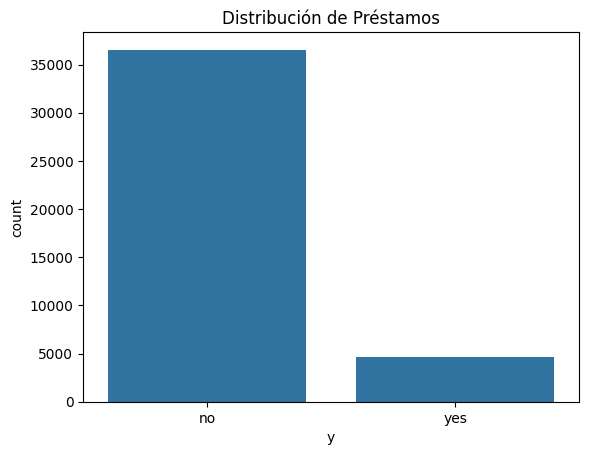

In [ ]:
# Contar valores de la variable objetivo
sns.countplot(x='y', data=df)
plt.title('Distribución de la contratación del préstamo')
plt.show()

In [ ]:
# Media de clientes que ya tienen contratado el servicio
total_yes = df[df['y']=='yes'].value_counts().sum()
mean_yes = (total_yes / len(df) * 100)

# Media de clientes que no han contratado anteriormente un depósito a largo plazo
total_no = df[df['y']=='no'].value_counts().sum()
mean_no = (total_no / len(df) * 100)
f'La media de los clientes que ya han contratado el servicio es {mean_yes.item()} y la de los que no lo han hecho anteriormente es {mean_no.item()}.'
 

'La media de los clientes que ya han contratado el servicio es 11.265417111780131 y la de los que no lo han hecho anteriormente es 88.73458288821988.'

#### (2) **Columnas predictoras**

##### (2.1) **Categóricas**

**Columna 'default': ¿El cliente tiene contratado un préstamos actualmente?**

In [11]:
df["default"].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

**Columna 'housing': ¿Tiene un préstamo de vivienda?**


In [37]:
df["housing"].value_counts()

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

**Columna 'loan': ¿Tiene un préstamo personal?**

In [38]:
df["loan"].value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

##### (2.2) **Numéricas**

**Columna 'age': ¿Cuál es el rango más amplio de edades de los clientes?**

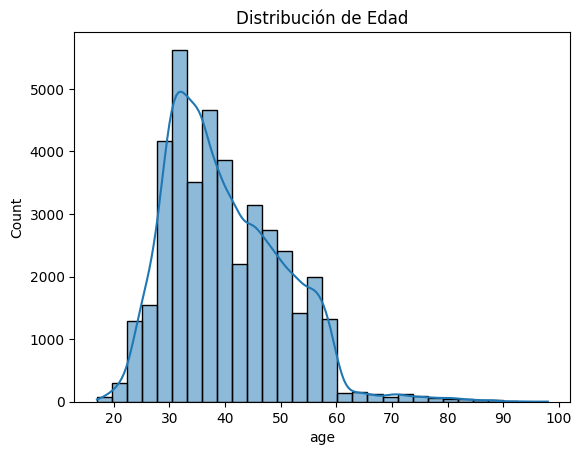

In [26]:
# Gráficos de distribución
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribución de Edad')
plt.show()



* La mayor parte de los clientes tienen entre 30 y 40 años.

## PASO 3. **Limpieza de datos**

## PASO 4. **Análisis de variables**

#### **Categóricas Discretas**

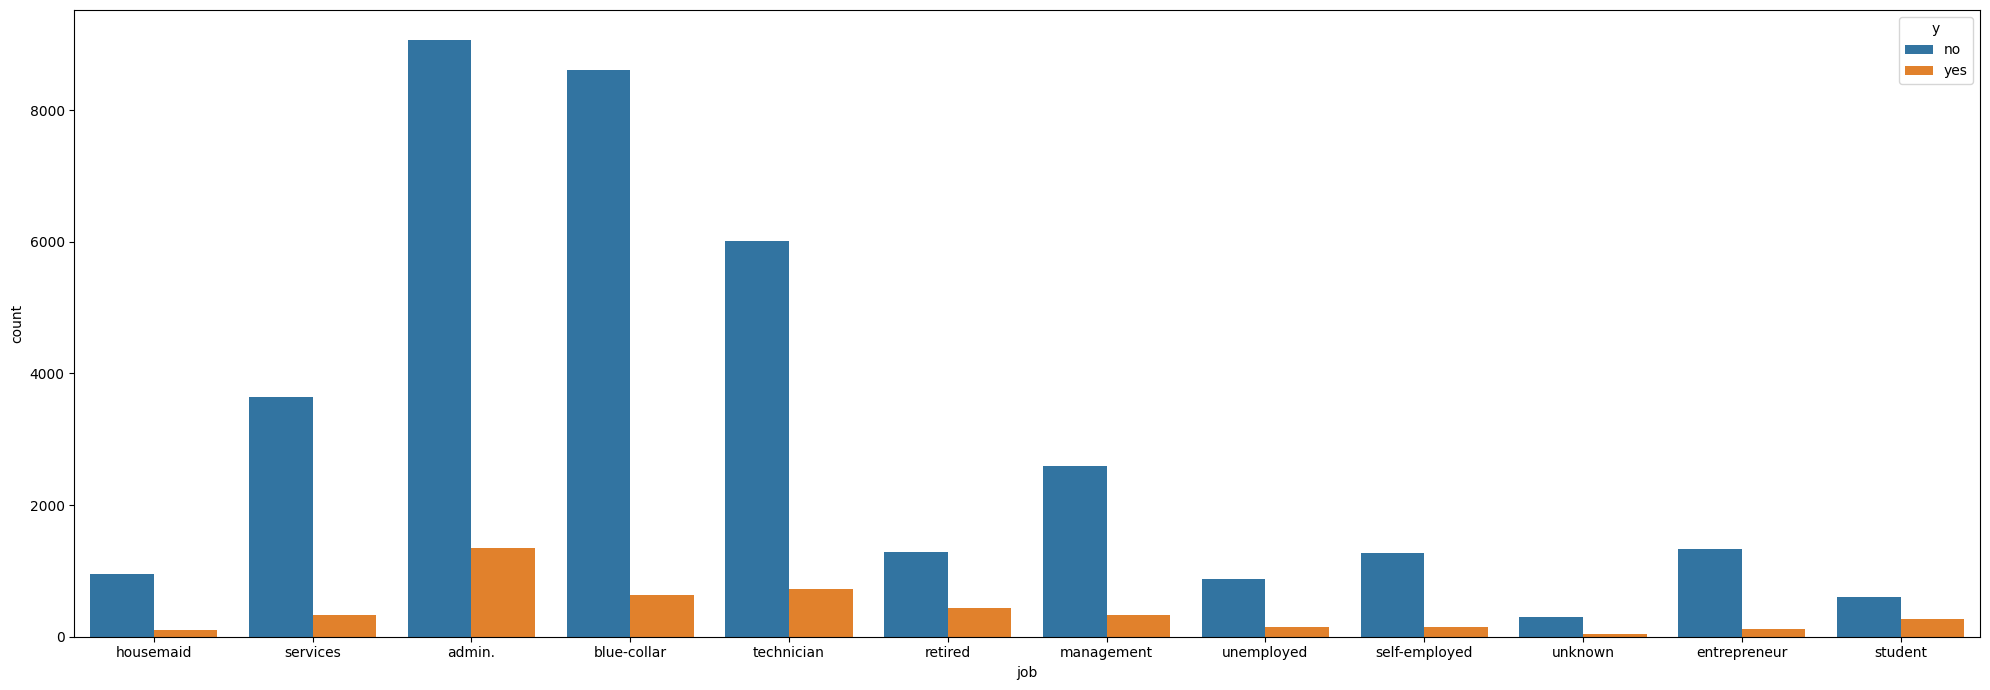

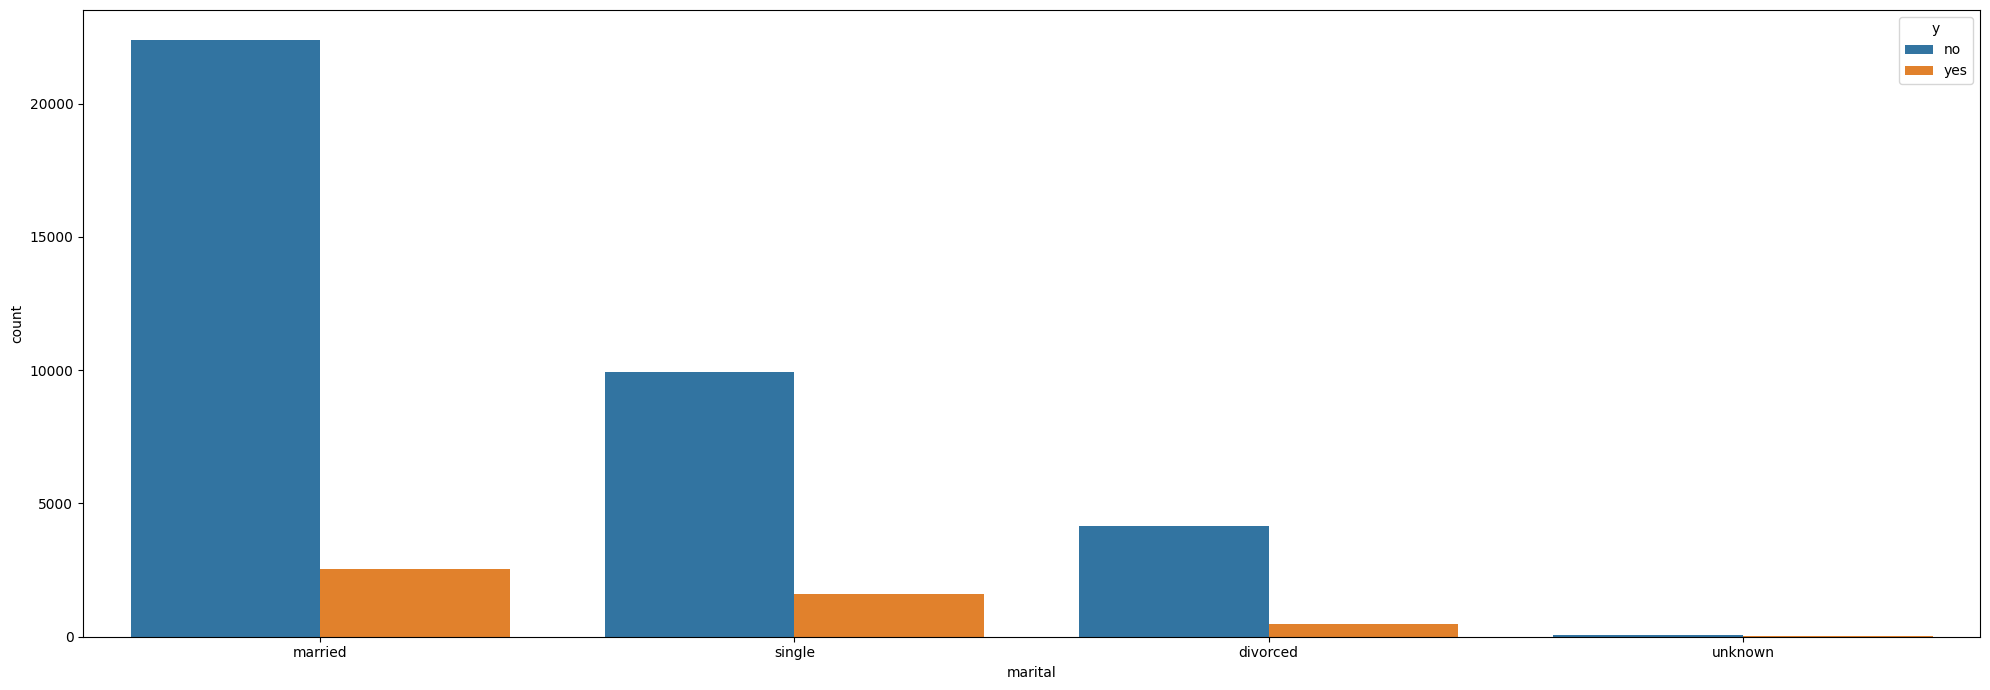

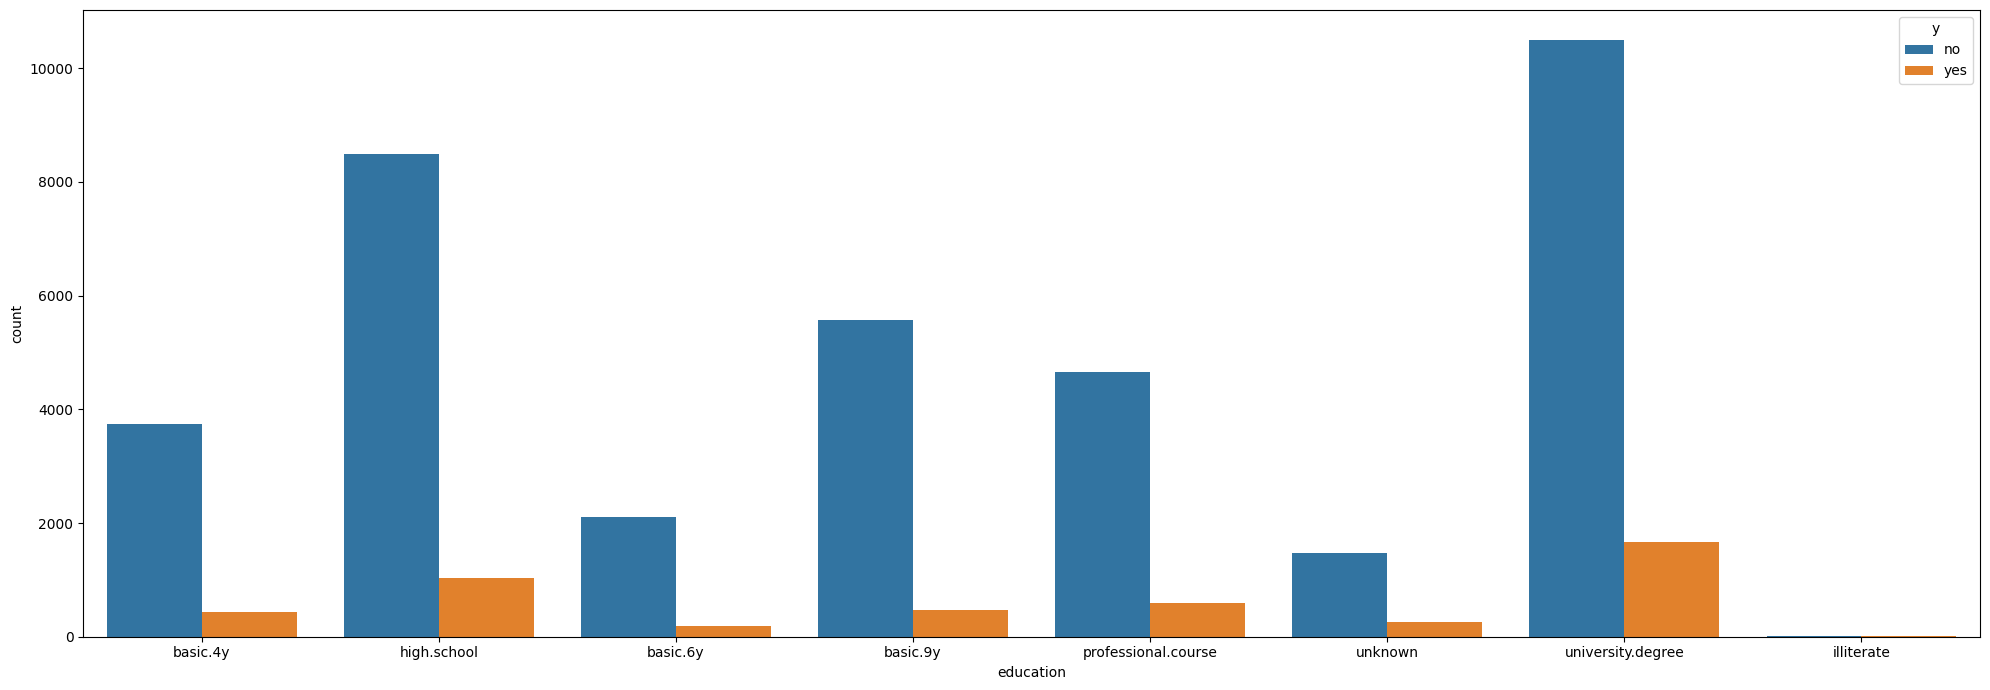

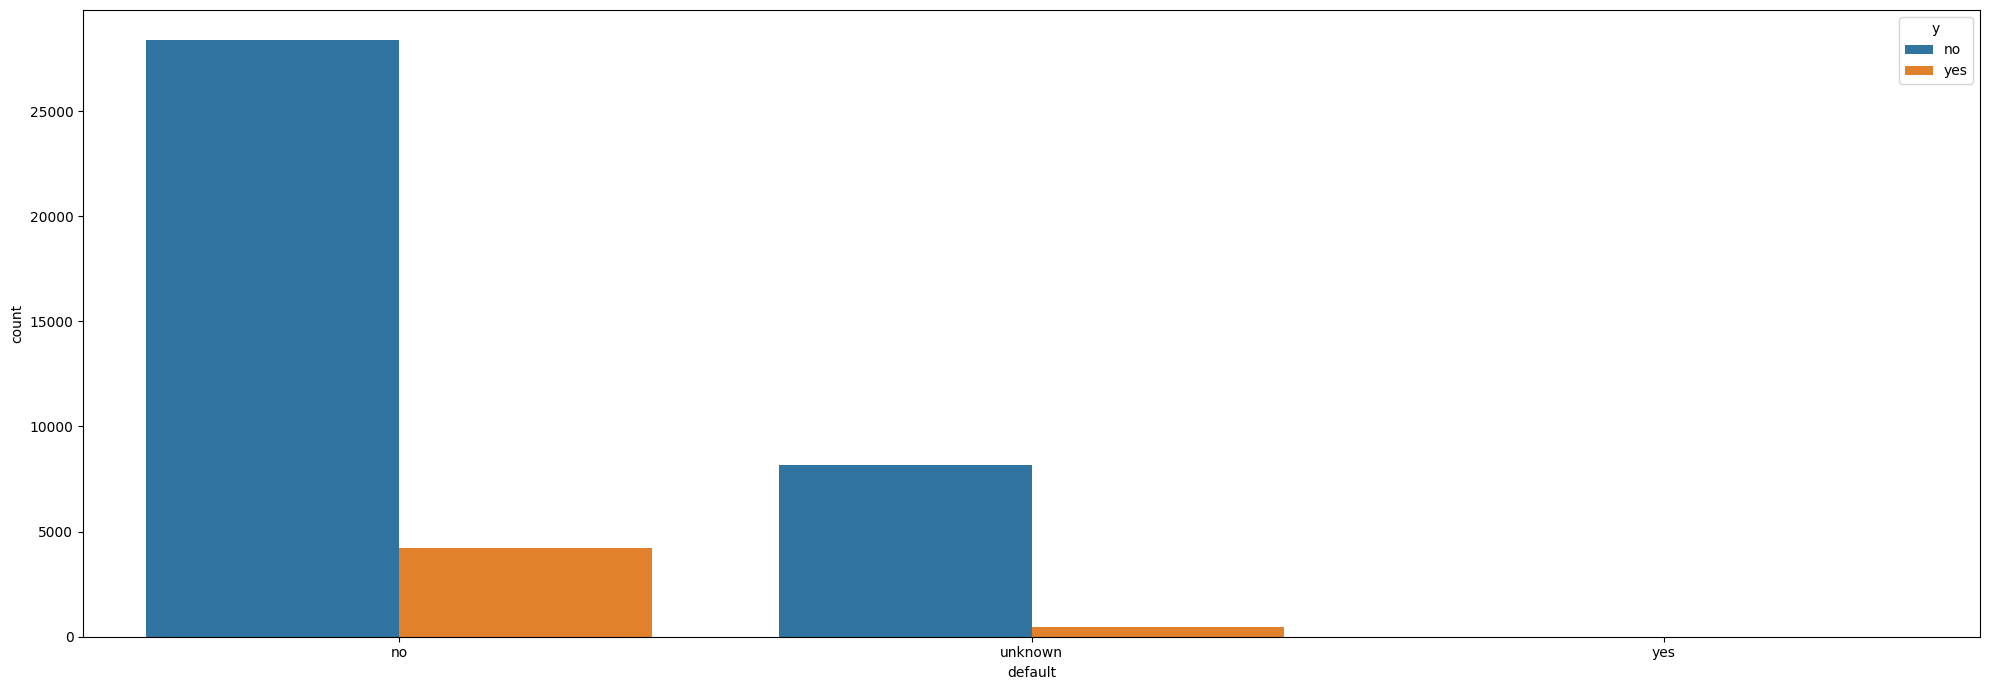

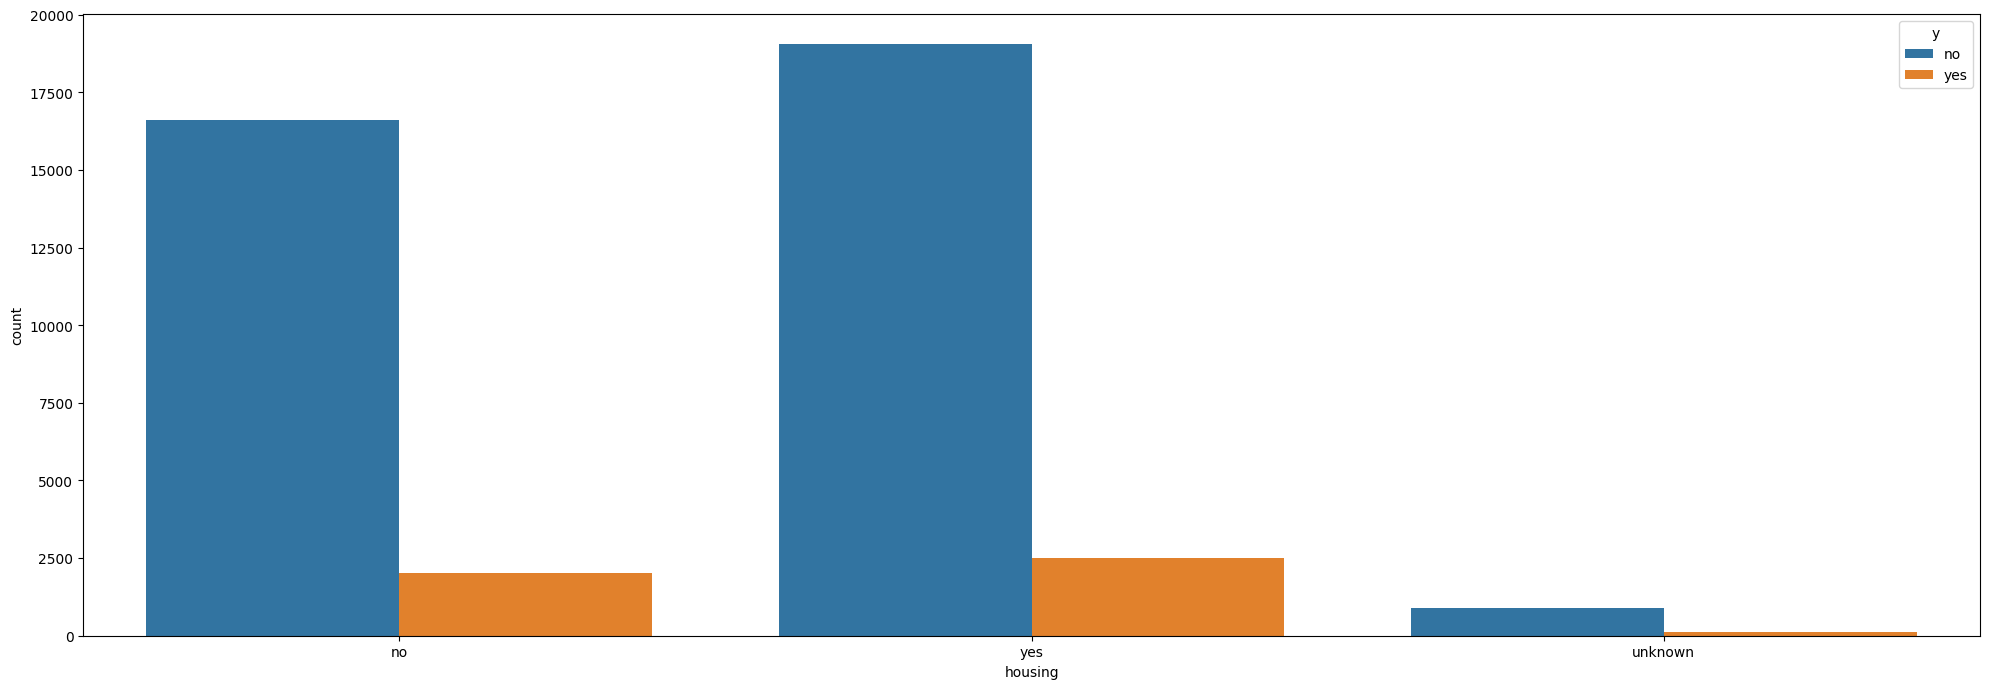

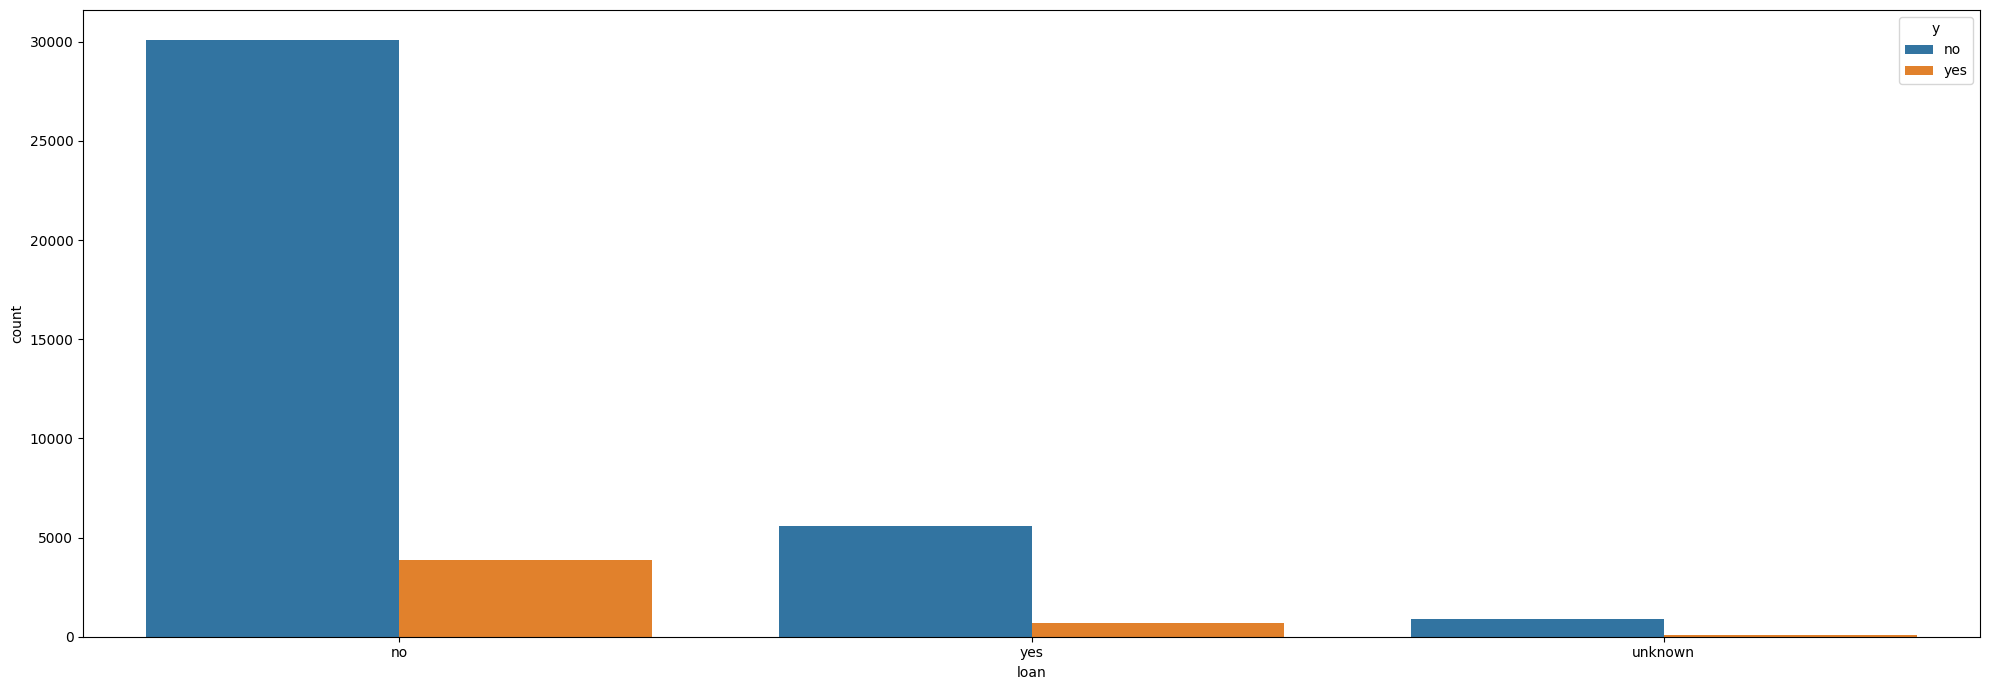

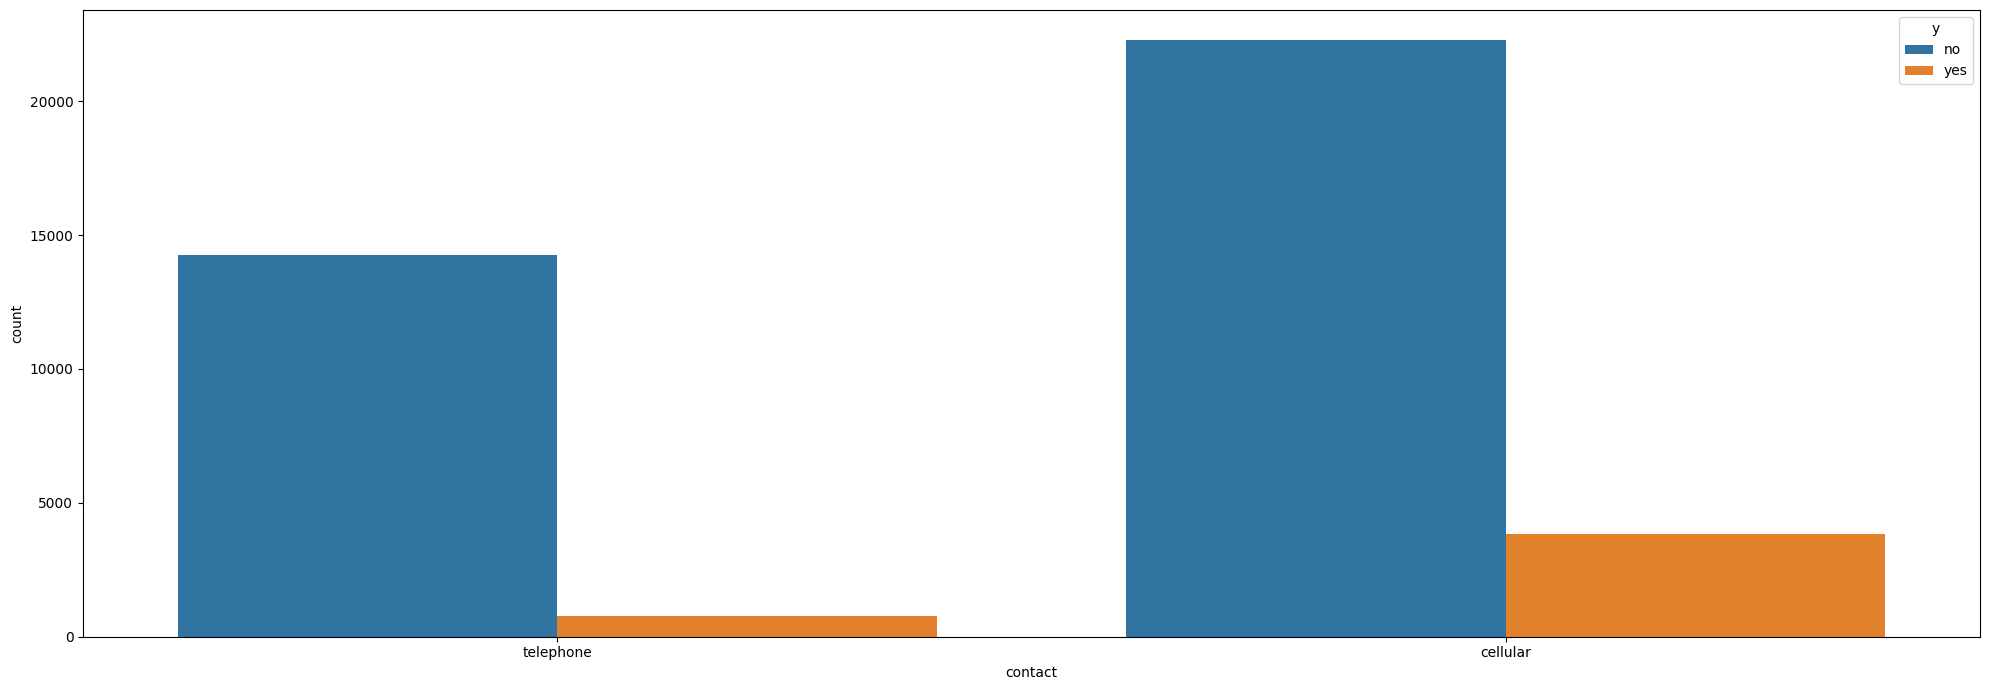

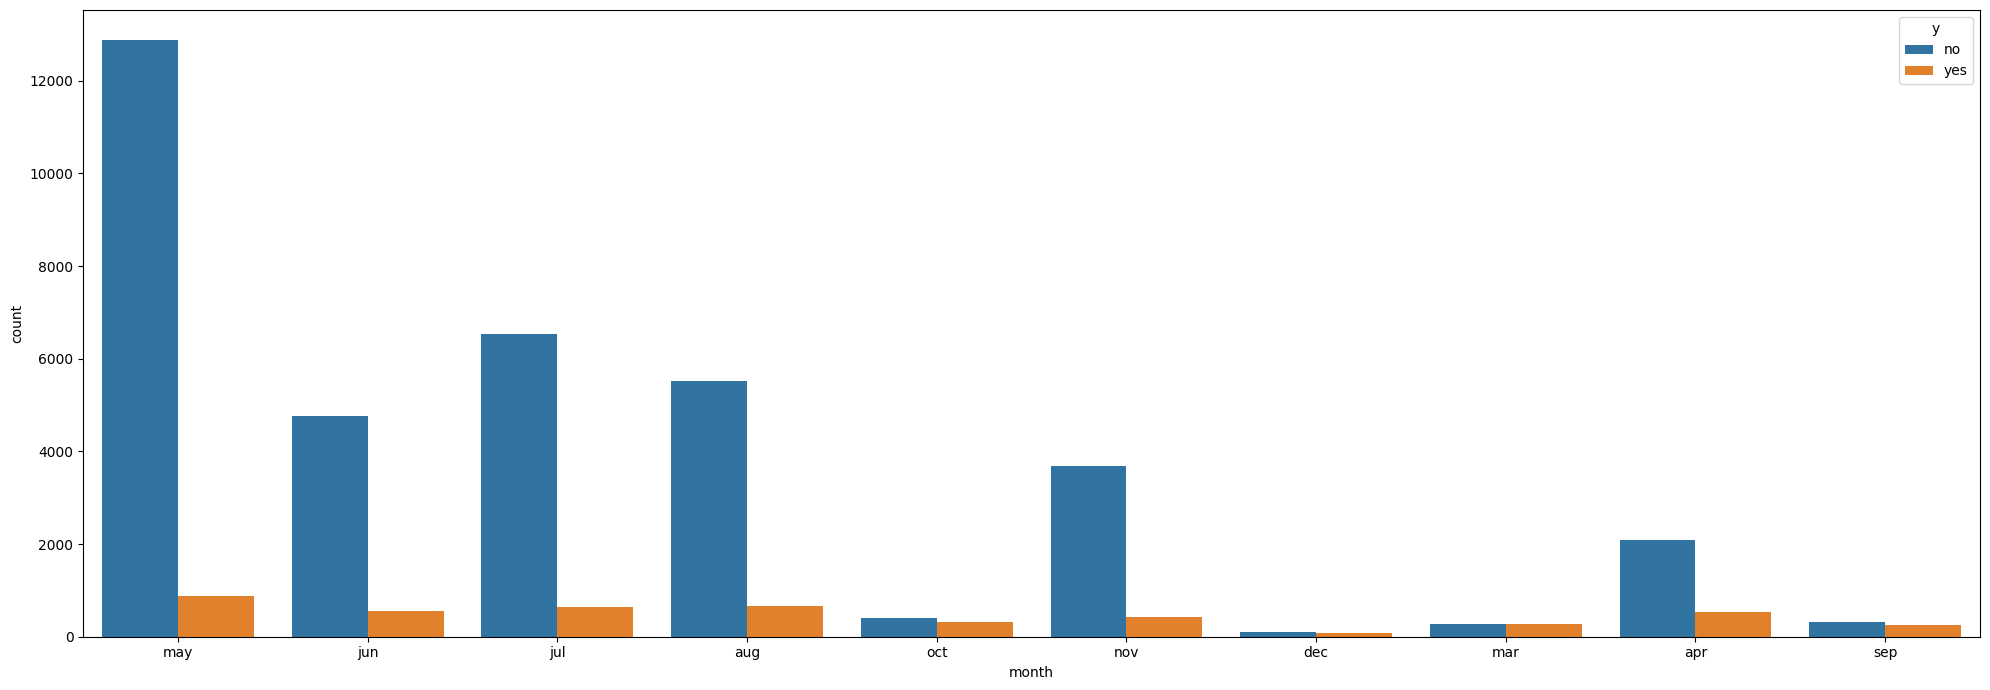

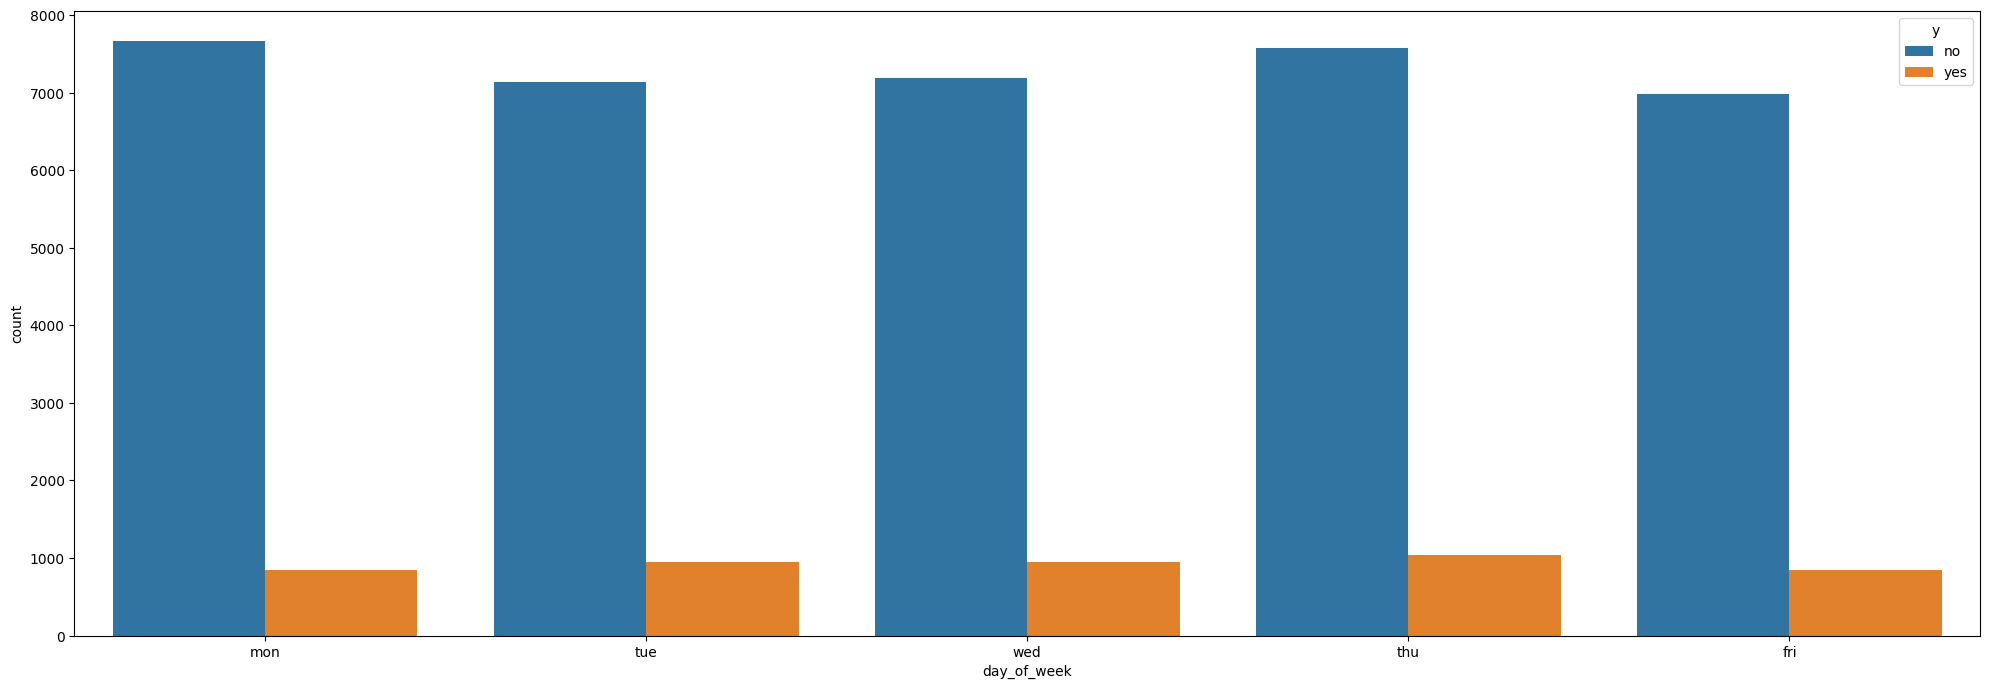

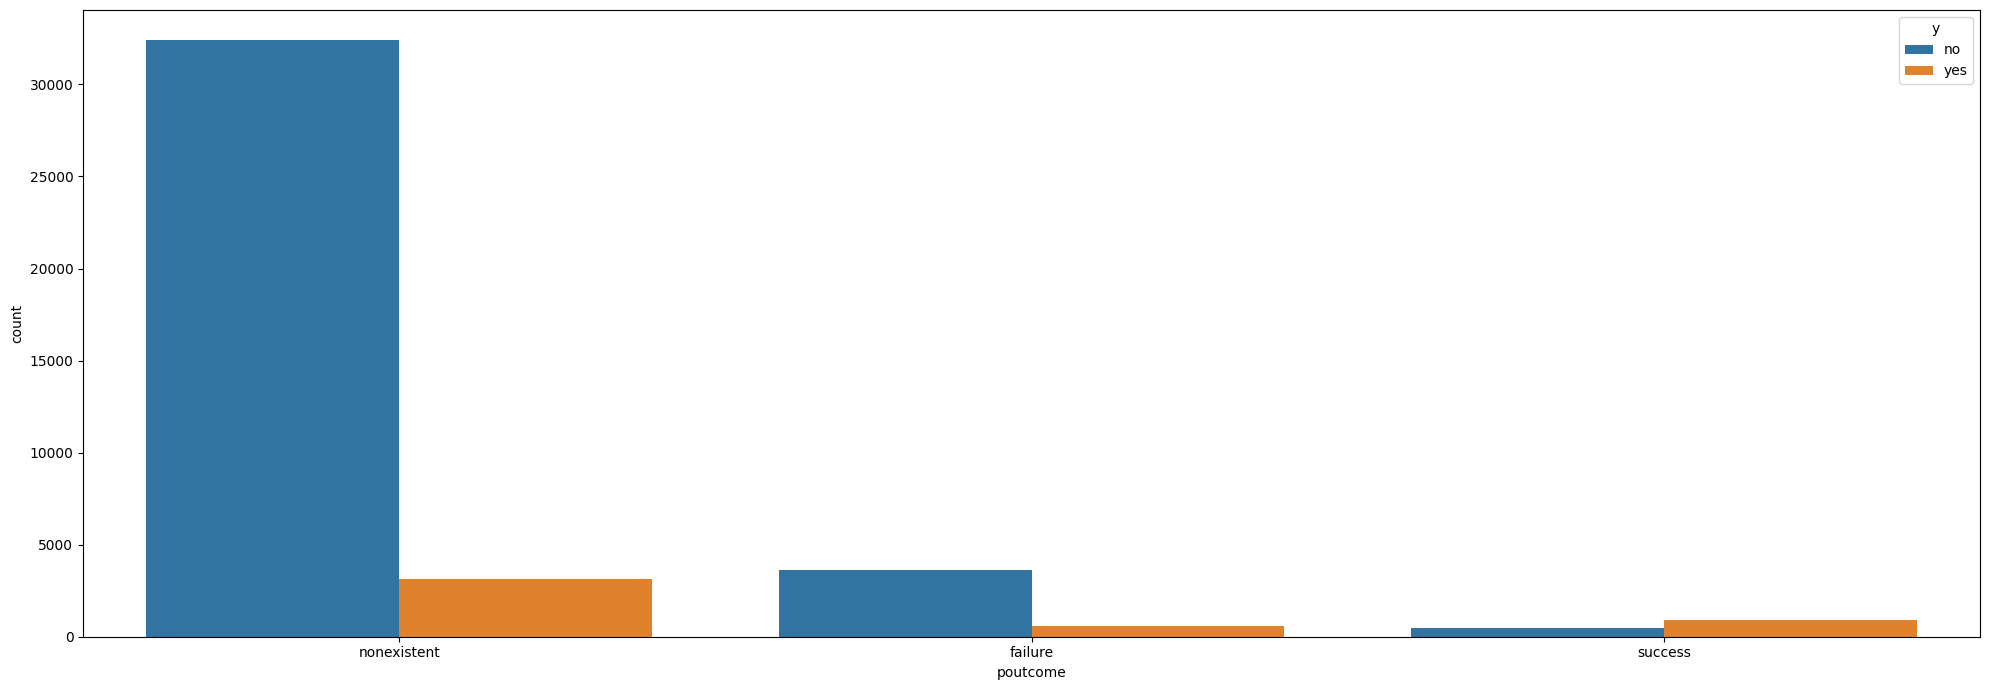

In [21]:
categorical_discret_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]
for column in categorical_discret_cols:
    fig, axis = plt.subplots(figsize=(20, 7))
    sns.countplot(data=df, x=column, hue="y")
    plt.tight_layout()
    plt.show()

#### **Numéricas general**

In [ ]:

numeric_cols = ["age", "duration", "campaign","pdays", "previous","emp.var.rate", "cons.price.idx","cons.conf.idx", "euribor3m", "nr.employed"]

for columna in numeric_cols:
    plt.figure(figsize=(15,6))
    sns.boxplot(data=df, x='y', y=columna)
    plt.title(f"Distribución de {columna} según target")
    plt.tight_layout()
    plt.show()

## **Análisis de correlaciones**

* Matriz de Correlación: Puedes observar la correlación entre las variables independientes y la variable objetivo para identificar relaciones.

* Interpretación de ResultadosVariables con alta correlación positiva: Indican que a medida que aumenta la variable, también lo hace la probabilidad de que el cliente contrate un préstamo.

* Variables con alta correlación negativa: Indican que a medida que aumenta la variable, disminuye la probabilidad de que el cliente contrate un préstamo.

* Coeficientes: Un coeficiente alto (positivo o negativo) indica una alta importancia.

In [46]:
df_factorize = df.copy()

df_factorize['default_y'] = pd.factorize(df['default'])[0]
df_factorize['matrial_y'] = pd.factorize(df['marital'])[0]
df_factorize['job_y'] = pd.factorize(df['job'])[0]
df_factorize['ducation_y'] = pd.factorize(df['education'])[0]
df_factorize['housing_y'] = pd.factorize(df['housing'])[0]
df_factorize['loan_y'] = pd.factorize(df['loan'])[0]
df_factorize['contact_y'] = pd.factorize(df['contact'])[0]
df_factorize['poutcome_y'] = pd.factorize(df['poutcome'])[0]
df_factorize['y_y'] = pd.factorize(df['y'])[0]

df_numerico = df_factorize.select_dtypes(include=['number'])

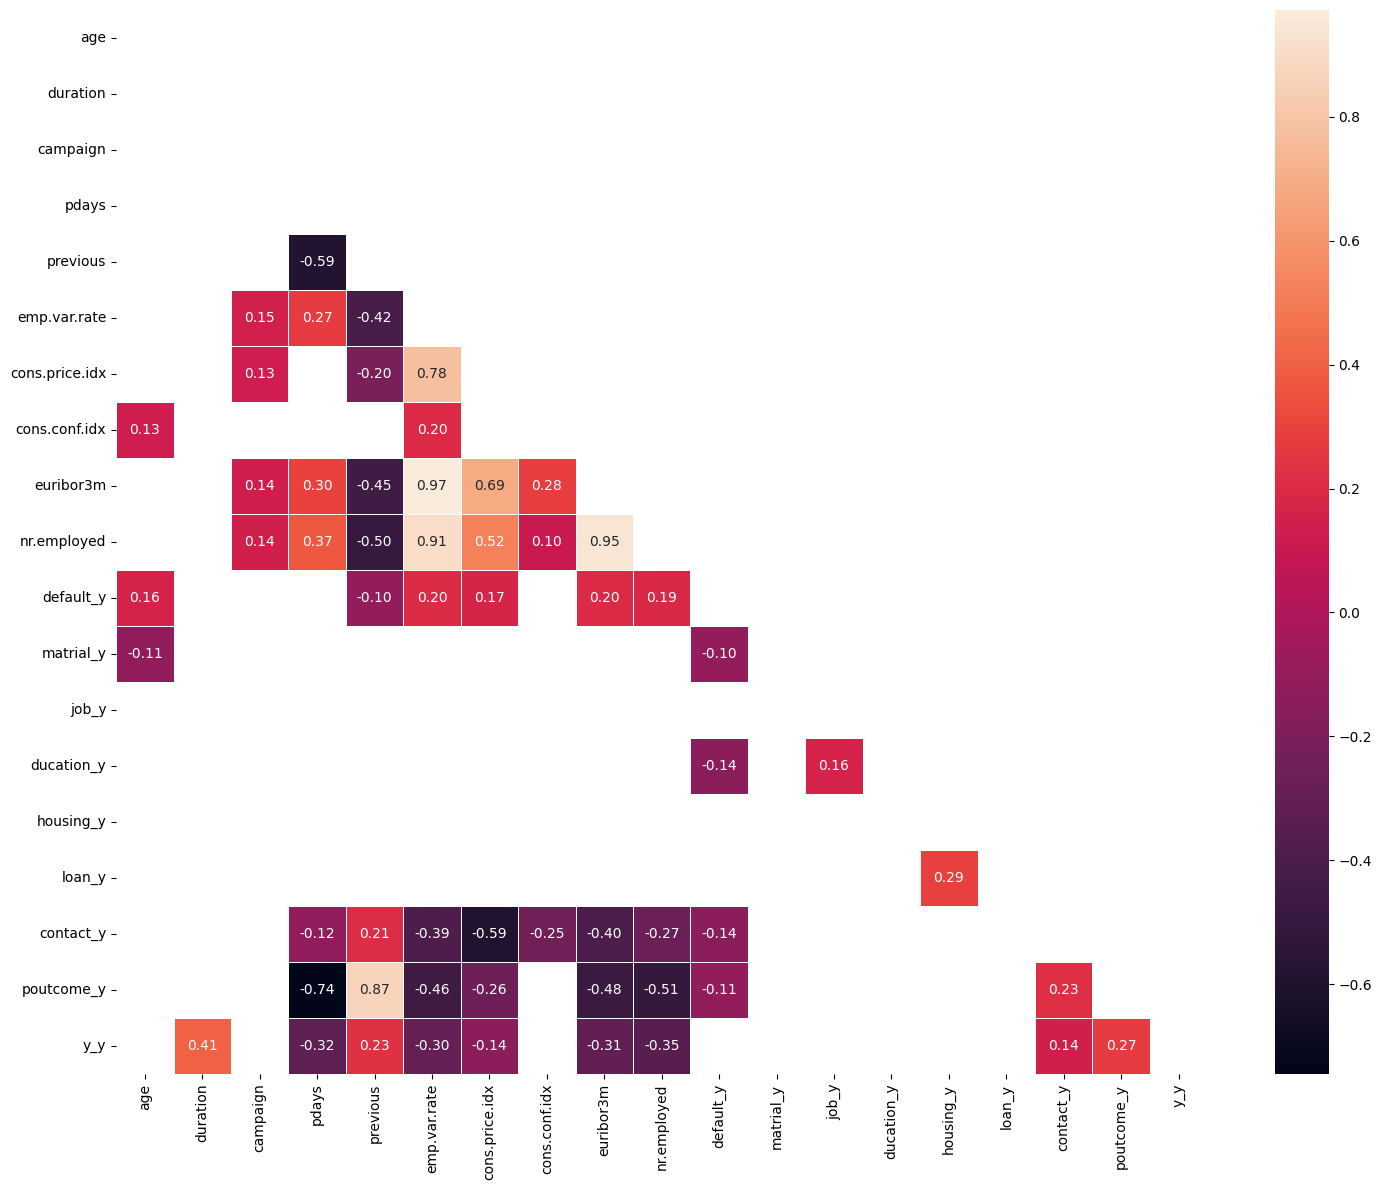

In [47]:
# Calcular la matriz de correlación
corr = df_numerico.corr()

# Visualizar la correlación con la variable objetivo
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

In [ ]:

# Boxplot de una variable categórica vs. la variable objetivo
sns.boxplot(x='prestamo', y='ingresos', data=df)
plt.title('Ingreso por Préstamo')
plt.show()

## Checklist general de EDA (para pegar en la pared)

1. Entender el problema y cada fila.
2. Mirada rápida a los datos.
3. Revisar estructura y tipos.
4. Buscar valores faltantes.
5. Buscar duplicados.
6. Analizar variables numéricas.
7. Analizar variables categóricas.
8. Analizar fechas/tiempo (si hay).
9. Analizar texto libre (si hay).
10. Ver relación con la variable objetivo.
11. Buscar correlaciones y multicolinealidad.
12. Buscar outliers y valores raros.
13. Pensar en calidad del dato y “sentido de negocio”.
14. Anotar conclusiones y decisiones (drop, imputar, transformar, etc.).





# EDA CookBook

## Paso 1: Entender el problema y la fila

**Objetivo:** saber qué significa cada fila y qué queremos predecir.

**Pasos (sin código):**

* Preguntar:

  * ¿Qué representa una fila? ¿Un cliente, una compra, una medición de sensor…?
  * ¿Qué queremos predecir o explicar? → **target** (columna objetivo).
  * ¿Qué columnas solo se conocen después del resultado? (posible leakage)

**Nota:**
Si no saben qué significa una columna → *anotar la duda* y no usarla para modelar hasta entenderla.




**Respuesta:** La dataset se refiere a información de potenciales compradores/adquirientes de un depósito bancario. Cada fila se refiere a los datos de una persona en cuanto a su edad, empleo, estado civil/marital, tipo de vivienda/residencia, datos sobre si ha sido contactado en campañas previas y datos sobre su empleabilidad.

## Paso 2: Mirada rápida al dataset

**Objetivo:** tener una idea general del tamaño y forma.

```python
df.shape          # (filas, columnas)
df.head()         # primeras filas
df.tail()         # últimas filas
df.sample(5, random_state=0)  # filas aleatorias
```

**Qué mirar:**

* ¿Hay columnas raras (todo 0, todo igual, códigos raros)?
* ¿El tamaño tiene sentido (no son 10 filas cuando esperabas miles)?




In [12]:
df.shape

(41188, 21)

In [13]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [14]:
# Para encontrar valores faltantes
df.isna().sum().sort_values(ascending=False)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

## Paso 3: Estructura y tipos de datos

**Objetivo:** saber si las columnas están con el tipo correcto.

```python
df.info()
df.dtypes
```

**Trucos:**

* IDs → normalmente `object` o `int` pero **no se usan para modelos** (solo como identificadores).
* Fechas que aparecen como texto → convertir a datetime:

```python
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
```

* Variables numéricas que en realidad son categorías (ej. “1=Bajo, 2=Medio, 3=Alto”) → tratarlas como categóricas.




## Paso 4: Valores faltantes (NaN)

**Objetivo:** ver dónde falta información.

```python
df.isna().sum()            # por columna
(df.isna().mean()*100)     # % de NaN por columna
```

**Qué mirar:**

* Columnas con **muchos NaN** (ej. > 40–50%).
* Columnas con **0 NaN** (quizás ya fueron imputadas o son obligatorias).

**Decisiones típicas (para explicar simple):**

* **Pocos NaN** → rellenar con:

  * numéricos: media/mediana o un valor especial (ej. -1).
  * categóricos: valor “Desconocido”.
* **Muchísimos NaN** → considerar eliminar la columna.
* NaN que tienen significado (ej. “no tiene segunda dirección”) → inventar categoría “No aplica”.

Ejemplo:

```python
# numérica
df["edad"] = df["edad"].fillna(df["edad"].median())

# categórica
df["ciudad"] = df["ciudad"].fillna("Desconocido")
```



## Paso 5: Duplicados

**Objetivo:** ver si hay filas repetidas.

```python
df.duplicated().sum()
df[df.duplicated()].head()
```

Para eliminarlos:

```python
df = df.drop_duplicates()
```

**Nota:**
A veces no es “toda la fila” duplicada, sino un ID repetido → hay que decidir si es un error o son eventos diferentes.




## Paso 6.1: Variables numéricas (visión general)

**Objetivo:** ver rangos, medias y valores raros.

```python
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols].describe()
```

**Trucos:**

* Mirar si hay valores imposibles (edad negativa, salario 1e9, etc.).
* Ver si hay columnas casi constantes (máx ≈ mín).




## Paso 6.2: Variables numéricas (distribuciones)

**Objetivo:** ver la forma de cada variable (sesgo, cola larga, etc.).

Ejemplo con una columna:

```python
col = "edad"
df[col].hist(bins=30)
plt.xlabel(col)
plt.ylabel("Frecuencia")
plt.show()
```

**Qué ver:**

* **Simétrico**: parecido a una campana.
* **Sesgado a la derecha**: muchos valores pequeños y pocos muy grandes (típico en ingresos, tiempos, montos).
* **Sesgado a la izquierda**: al revés.

**Ideas de acciones simples:**

* Distribución muy sesgada → considerar logaritmo:
  `df["ingreso_log"] = np.log1p(df["ingreso"])`

Transformamos para que los modelos puedan entender mejor. No queremos colas extremas dominantes o escalas desproporcionadas. Aunque estas transformaciones no son necesarias para todos los modelos.




## Paso 7.1: Variables categóricas (conteos)

**Objetivo:** ver cuántas categorías hay y cuáles son las más frecuentes.

```python
cat_cols = df.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))
    print("N categorías:", df[col].nunique())
```

**Trucos:**

* Columnas con **demasiadas categorías** (ej. texto libre, IDs) → cuidado para modelos.
* Categorías muy raras → se pueden agrupar en “Otros”.




## Paso 7.2: Variables categóricas (gráficos simples)

Ejemplo: distribución de una categoría.

```python
col = "ciudad"
df[col].value_counts().head(10).plot(kind="bar")
plt.ylabel("Cuenta")
plt.show()
```

**Qué mirar:**

* Categorías dominantes (ej. una ciudad es 90% de los casos).
* Categorías casi sin datos (quizás no valga la pena usarlas).




## Paso 8: Fechas y tiempo

**Objetivo:** aprovechar columnas de fecha.

Asumimos que ya convertiste la columna:

```python
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
```

**Crear columnas derivadas fáciles:**

```python
df["anio"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month
df["dia_semana"] = df["fecha"].dt.day_name()
```

**Analizar evolución en el tiempo:**

```python
df_por_mes = df.groupby(["anio", "mes"])["target"].mean()  # o count
df_por_mes.plot()
plt.ylabel("Target medio")
plt.show()
```

**Nota:** ver si hay **tendencias** o **estacionalidad** (por meses, días de semana).




## Paso 9: Texto libre (muy básico)

**Objetivo:** tener idea de qué trae una columna de texto.

```python
df["comentario"].str.len().describe()  # longitud de texto
df["comentario"].head()
```

Trucos muy simples:

* Crear una columna con la **longitud del texto**:

  ```python
  df["len_comentario"] = df["comentario"].str.len()
  ```
* Contar cuántos están vacíos o muy cortos:

  ```python
  (df["comentario"].str.len() == 0).mean()
  ```




## Paso 10: Relación con la variable objetivo (clasificación)

### 10.1. Numérica vs target binario (0/1)

**Objetivo:** ver si la variable ayuda a separar clases.

```python
col = "edad"
df.groupby("target")[col].describe()
```

**Explicación simple:**
Comparar la media de `edad` para target=0 y target=1.
Si son muy diferentes, esa variable probablemente sea útil.



### 10.2. Categoría vs target binario

```python
col = "ciudad"
tabla = (
    df.groupby(col)["target"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
print(tabla)
```

**Qué mirar:**
Ciudades con tasa de target mucho más alta o más baja → categorías importantes.





## Paso 11: Correlaciones (numéricas)

**Objetivo:** ver qué variables numéricas se parecen (se mueven juntas).

```python
corr = df[num_cols].corr()
corr["target"].sort_values(ascending=False)
```

**Que significa:**

* Correlación cerca de **1**: suben y bajan juntas.
* Cerca de **-1**: una sube cuando la otra baja.
* Cerca de **0**: no hay relación lineal clara.

También ver **correlaciones entre variables predictoras**:

* Si dos columnas están casi perfectamente correlacionadas → quizás una sobra.




## Paso 12: Outliers (valores extremos)

### 12.1. Por regla simple

```python
col = "ingreso"
df[col].describe()
```

Luego:

```python
# Filas con valores muy grandes
df[df[col] > df[col].quantile(0.99)].head()
```

### 12.2. Boxplot simple

```python
df[[col]].boxplot()
plt.show()
```

**Nota:**

* Un outlier no siempre es un error.
* Preguntar: ¿es un error de carga o un cliente realmente enorme?
* Opciones simples: recortar (cap), transformar (log), o dejarlos pero avisar al modelo.




## Paso 13.1: Columnas inútiles o sospechosas

**Checklist simple:**

* Columnas **idénticas** o muy similares entre sí.
* Columnas con **un solo valor** (sin variabilidad).
* IDs puros (no explican nada, solo identifican).
* Columnas que se conocen **después** del resultado (leakage).

Código rápido:

```python
# columnas casi constantes
n = len(df)
for col in df.columns:
    freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if freq > 0.99:
        print("Casi constante:", col, f"({freq:.2%} mismo valor)")
```




## Paso 13.2: Data leakage (explicación simple)

**Objetivo:** evitar “hacer trampa”.

**Ejemplos:**

* Predecir si un cliente dejará la empresa usando una columna “fecha_de_baja”.
* Predecir ventas del mes usando la columna “ventas_del_mes” 🤦.

**Regla de oro:**

> Si la columna no estaría disponible en el momento real de hacer la predicción, no puede usarse.




## Paso 14: Crear reporte y/o pipeline

Anotar conclusiones y decisiones (drop, imputar, transformar, etc.) para poder replicar en otros datasets (train, test o actualizaciones) o experimentos.

## Paso 15 (bonus): Reporte rápido automático

- [sweetviz](https://colab.research.google.com/github/amiune/freecodingtour/blob/main/cursos/espanol/datascience/analysis/A1.2_eda_sweetviz.ipynb)
- [pandas_dq](https://colab.research.google.com/github/amiune/freecodingtour/blob/main/cursos/espanol/datascience/analysis/A3.3_pandas_dq.ipynb)
-[mas...](https://colab.research.google.com/github/amiune/freecodingtour/blob/main/cursos/espanol/datascience/analysis/A0_intro.ipynb#scrollTo=48149491-163e-4f79-a52a-91e027f85bf5)

# Paso 16 (extra bonus): Ver distintos analisis en kaggle

- https://www.kaggle.com/datasets/saritas95/nyc-airbnb-insights-a-data-analysis
- https://www.kaggle.com/code/phongphmlm/airbnb-new-york-city-2019
- https://www.kaggle.com/code/dgomonov/data-exploration-on-nyc-airbnb
- https://www.kaggle.com/code/chbenitez/airbnb-nyc-an-lisis-y-preprocesamiento-de-datos/notebook
- https://www.kaggle.com/code/duygut/airbnb-nyc-price-prediction

# ML

## Paso 0. **Imports ML Regresión Logística**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Paso 1. **Split data**

**Dividir datos en características y variable objetivo**

In [ ]:
X = df.drop('prestamo', axis=1)
y = df['prestamo']

**Dividir en conjunto de entrenamiento y prueba**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Paso 2. **Crear el modelo**

**Regression Logística**

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

## Paso 3. **Predicciones**

In [ ]:

y_pred = model.predict(X_test)

## Paso 4. **Evaluación del modelo (Regresión Logística)**

* Modelo de Regresión Logística: Los coeficientes del modelo pueden indicar la importancia de cada variable



### **Correlaciones de las variables en el modelo entrenado**

In [ ]:
# Obtener los coeficientes del modelo
coefficients = pd.DataFrame(model.coef_[0], index=X.columns, columns=['Coefficient'])
coefficients['Importance'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Importance', ascending=False)

print(coefficients)

In [ ]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))